Notebook 04 : Analyse des Coûts Business (Faux Positifs/Négatifs)

SECTION 1 : IMPORTATION ET CHARGEMENT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

print("📊 ANALYSE DES COÛTS BUSINESS")
print("="*80)

# Charger le modèle et les prédictions
model_data = joblib.load('../data/processed/all_models.pkl')
best_model = model_data['best_model']

processed_data = joblib.load('../data/processed/processed_data.pkl')
X_test = processed_data['X_test']
y_test = processed_data['y_test']

# Prédictions
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print(f"✅ Données chargées")
print(f"   Test set: {len(y_test)} clients")

📊 ANALYSE DES COÛTS BUSINESS
✅ Données chargées
   Test set: 1407 clients


SECTION 2 : MATRICE DE CONFUSION ET COÛTS

In [2]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 MATRICE DE CONFUSION:")
print(f"   True Negatives (TN):  {tn} - Clients correctement prédits NO CHURN")
print(f"   False Positives (FP): {fp} - FAUSSES ALERTES (prédit Churn mais reste)")
print(f"   False Negatives (FN): {fn} - CHURNS MANQUÉS (prédit No Churn mais part)")
print(f"   True Positives (TP):  {tp} - Churns correctement détectés")



📊 MATRICE DE CONFUSION:
   True Negatives (TN):  741 - Clients correctement prédits NO CHURN
   False Positives (FP): 292 - FAUSSES ALERTES (prédit Churn mais reste)
   False Negatives (FN): 72 - CHURNS MANQUÉS (prédit No Churn mais part)
   True Positives (TP):  302 - Churns correctement détectés


SECTION 3 : ANALYSE DES COÛTS BUSINESS

In [3]:
print(f"\n💰 ANALYSE DES COÛTS BUSINESS")
print("="*80)

# Paramètres business (du document)
MONTHLY_REVENUE_PER_CLIENT = 850  # FCFA
ANNUAL_REVENUE_PER_CLIENT = MONTHLY_REVENUE_PER_CLIENT * 12  # 10,200 FCFA

# Coûts des actions
COST_RETENTION_ACTION = 5_000  # FCFA (offre de rétention)
COST_FALSE_POSITIVE = COST_RETENTION_ACTION  # Coût d'une fausse alerte

# Coût d'un churn manqué = perte du client
COST_FALSE_NEGATIVE = ANNUAL_REVENUE_PER_CLIENT  # 10,200 FCFA

print(f"\n📋 PARAMÈTRES BUSINESS:")
print(f"   Revenu mensuel/client: {MONTHLY_REVENUE_PER_CLIENT:,} FCFA")
print(f"   Revenu annuel/client: {ANNUAL_REVENUE_PER_CLIENT:,} FCFA")
print(f"   Coût action rétention: {COST_RETENTION_ACTION:,} FCFA")


💰 ANALYSE DES COÛTS BUSINESS

📋 PARAMÈTRES BUSINESS:
   Revenu mensuel/client: 850 FCFA
   Revenu annuel/client: 10,200 FCFA
   Coût action rétention: 5,000 FCFA


SECTION 4 : CALCUL DES COÛTS

In [4]:
# Coût total des faux positifs (fausses alertes)
total_cost_fp = fp * COST_FALSE_POSITIVE

# Coût total des faux négatifs (churns manqués)
total_cost_fn = fn * COST_FALSE_NEGATIVE

# Coût total actions de rétention (tous les positifs)
total_positives = fp + tp
total_cost_actions = total_positives * COST_RETENTION_ACTION

# Revenus sauvés (supposons 50% de succès sur les vrais positifs)
RETENTION_SUCCESS_RATE = 0.50
clients_saved = tp * RETENTION_SUCCESS_RATE
revenue_saved = clients_saved * ANNUAL_REVENUE_PER_CLIENT

print(f"\n💸 ANALYSE DES COÛTS:")
print(f"\n1. FAUX POSITIFS (Fausses Alertes):")
print(f"   Nombre: {fp}")
print(f"   Coût unitaire: {COST_FALSE_POSITIVE:,} FCFA")
print(f"   Coût total: {total_cost_fp:,} FCFA")
print(f"   Impact: Gaspillage d'argent sur clients non à risque")

print(f"\n2. FAUX NÉGATIFS (Churns Manqués) ❌ CRITIQUE:")
print(f"   Nombre: {fn}")
print(f"   Coût unitaire: {COST_FALSE_NEGATIVE:,} FCFA")
print(f"   Coût total: {total_cost_fn:,} FCFA")
print(f"   Impact: Clients perdus définitivement")

print(f"\n3. VRAIS POSITIFS (Churns Détectés) ✅:")
print(f"   Nombre: {tp}")
print(f"   Clients sauvés (50% succès): {clients_saved:.0f}")
print(f"   Revenus sauvés: {revenue_saved:,} FCFA")



💸 ANALYSE DES COÛTS:

1. FAUX POSITIFS (Fausses Alertes):
   Nombre: 292
   Coût unitaire: 5,000 FCFA
   Coût total: 1,460,000 FCFA
   Impact: Gaspillage d'argent sur clients non à risque

2. FAUX NÉGATIFS (Churns Manqués) ❌ CRITIQUE:
   Nombre: 72
   Coût unitaire: 10,200 FCFA
   Coût total: 734,400 FCFA
   Impact: Clients perdus définitivement

3. VRAIS POSITIFS (Churns Détectés) ✅:
   Nombre: 302
   Clients sauvés (50% succès): 151
   Revenus sauvés: 1,540,200.0 FCFA


SECTION 5 : ROI ET BILAN

In [5]:
# Coût total du système (actions + fausses alertes)
total_cost = total_cost_actions

# Revenu net (revenus sauvés - coûts)
net_revenue = revenue_saved - total_cost

# ROI
roi = (net_revenue / total_cost) * 100 if total_cost > 0 else 0

# Coût de ne rien faire (tous les churns partent)
total_churns = fn + tp
cost_do_nothing = total_churns * COST_FALSE_NEGATIVE

# Économie réalisée
savings = cost_do_nothing - (total_cost_fn + total_cost)

print(f"\n📈 BILAN FINANCIER:")
print(f"\n   SANS LE MODÈLE (ne rien faire):")
print(f"   • Clients qui partent: {total_churns}")
print(f"   • Perte totale: {cost_do_nothing:,} FCFA")

print(f"\n   AVEC LE MODÈLE:")
print(f"   • Coût actions rétention: {total_cost:,} FCFA")
print(f"   • Revenus sauvés: {revenue_saved:,} FCFA")
print(f"   • Clients encore perdus (FN): {fn}")
print(f"   • Coût FN: {total_cost_fn:,} FCFA")

print(f"\n   RÉSULTAT NET:")
print(f"   • Revenu net: {net_revenue:,} FCFA")
print(f"   • ROI: {roi:.1f}%")
print(f"   • Économie vs ne rien faire: {savings:,} FCFA")

if roi > 0:
    print(f"\n   ✅ Le modèle est RENTABLE !")
else:
    print(f"\n   ❌ Le modèle n'est pas rentable")


📈 BILAN FINANCIER:

   SANS LE MODÈLE (ne rien faire):
   • Clients qui partent: 374
   • Perte totale: 3,814,800 FCFA

   AVEC LE MODÈLE:
   • Coût actions rétention: 2,970,000 FCFA
   • Revenus sauvés: 1,540,200.0 FCFA
   • Clients encore perdus (FN): 72
   • Coût FN: 734,400 FCFA

   RÉSULTAT NET:
   • Revenu net: -1,429,800.0 FCFA
   • ROI: -48.1%
   • Économie vs ne rien faire: 110,400 FCFA

   ❌ Le modèle n'est pas rentable


SECTION 6 : ANALYSE PAR SEUIL


In [6]:
print(f"\n🎯 OPTIMISATION DU SEUIL (Trade-off FP vs FN)")
print("="*80)

thresholds = np.arange(0.3, 0.7, 0.05)
results = []

for threshold in thresholds:
    y_pred_t = (y_pred_proba >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    # Coûts
    cost_fp_t = fp_t * COST_FALSE_POSITIVE
    cost_fn_t = fn_t * COST_FALSE_NEGATIVE
    cost_actions_t = (fp_t + tp_t) * COST_RETENTION_ACTION
    revenue_saved_t = tp_t * RETENTION_SUCCESS_RATE * ANNUAL_REVENUE_PER_CLIENT
    net_revenue_t = revenue_saved_t - cost_actions_t
    
    results.append({
        'threshold': threshold,
        'tp': tp_t,
        'fp': fp_t,
        'fn': fn_t,
        'tn': tn_t,
        'cost_fp': cost_fp_t,
        'cost_fn': cost_fn_t,
        'revenue_saved': revenue_saved_t,
        'net_revenue': net_revenue_t
    })

df_results = pd.DataFrame(results)

# Trouver le seuil optimal (max revenu net)
best_idx = df_results['net_revenue'].idxmax()
best_threshold = df_results.loc[best_idx, 'threshold']

print(f"\n📊 ANALYSE PAR SEUIL:")
print(df_results.to_string(index=False))

print(f"\n🏆 SEUIL OPTIMAL BUSINESS: {best_threshold:.2f}")
print(f"   Revenu net maximal: {df_results.loc[best_idx, 'net_revenue']:,.0f} FCFA")
print(f"   FP: {df_results.loc[best_idx, 'fp']:.0f}")
print(f"   FN: {df_results.loc[best_idx, 'fn']:.0f}")
print(f"   TP: {df_results.loc[best_idx, 'tp']:.0f}")


🎯 OPTIMISATION DU SEUIL (Trade-off FP vs FN)

📊 ANALYSE PAR SEUIL:
 threshold  tp  fp  fn  tn  cost_fp  cost_fn  revenue_saved  net_revenue
      0.30 346 468  28 565  2340000   285600      1764600.0   -2305400.0
      0.35 337 439  37 594  2195000   377400      1718700.0   -2161300.0
      0.40 326 396  48 637  1980000   489600      1662600.0   -1947400.0
      0.45 314 349  60 684  1745000   612000      1601400.0   -1713600.0
      0.50 302 292  72 741  1460000   734400      1540200.0   -1429800.0
      0.55 291 249  83 784  1245000   846600      1484100.0   -1215900.0
      0.60 265 199 109 834   995000  1111800      1351500.0    -968500.0
      0.65 240 150 134 883   750000  1366800      1224000.0    -726000.0

🏆 SEUIL OPTIMAL BUSINESS: 0.65
   Revenu net maximal: -726,000 FCFA
   FP: 150
   FN: 134
   TP: 240


SECTION 7 : VISUALISATIONS

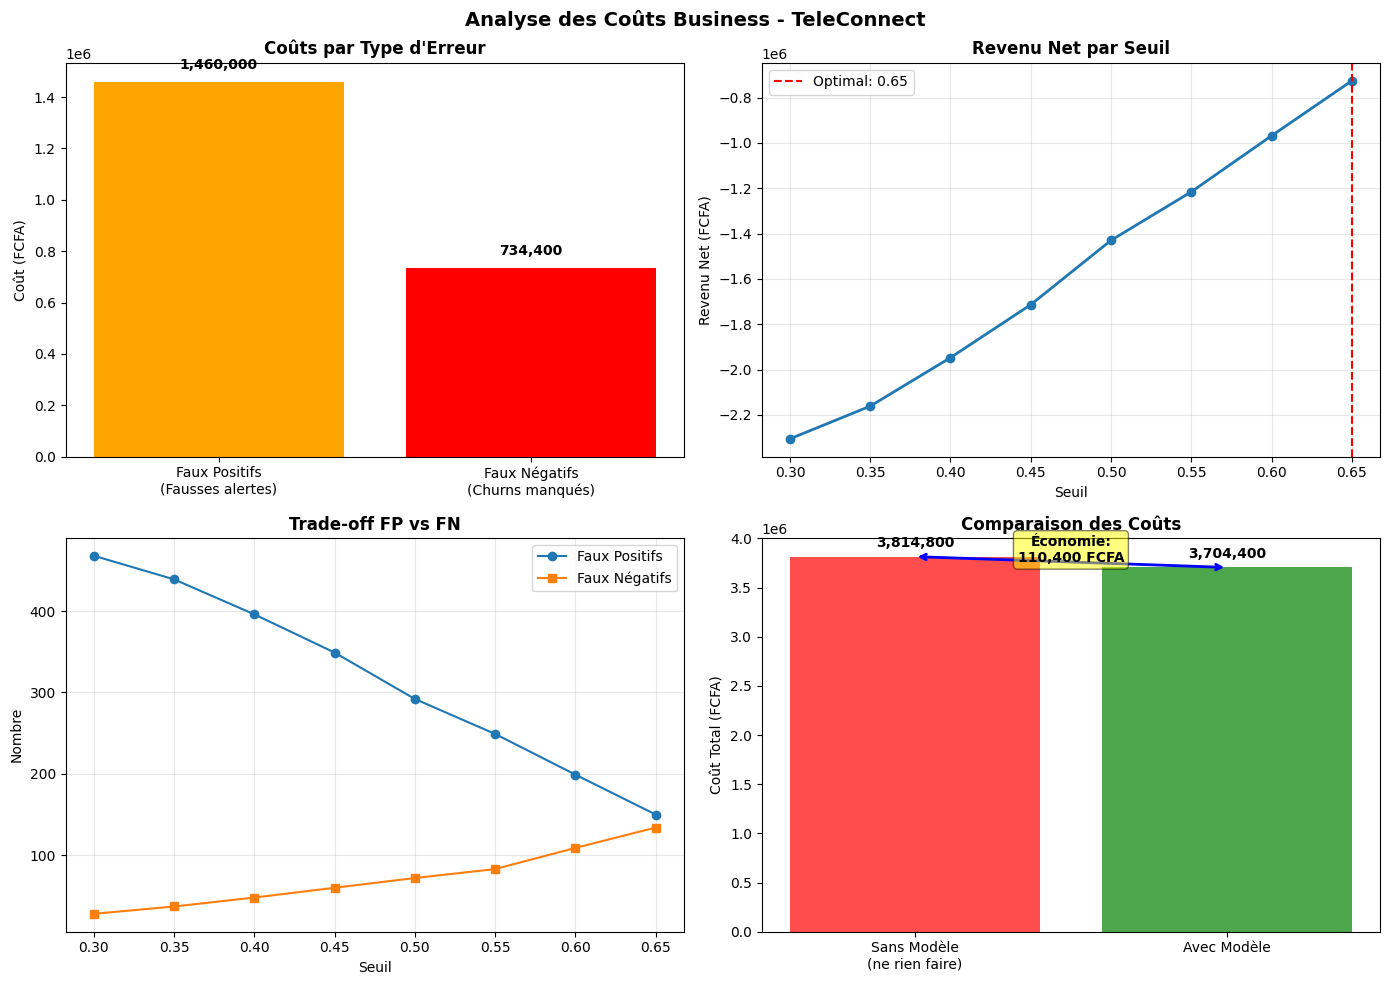

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Coûts par catégorie
categories = ['Faux Positifs\n(Fausses alertes)', 
              'Faux Négatifs\n(Churns manqués)']
costs = [total_cost_fp, total_cost_fn]
colors = ['orange', 'red']

axes[0, 0].bar(categories, costs, color=colors)
axes[0, 0].set_title('Coûts par Type d\'Erreur', fontweight='bold')
axes[0, 0].set_ylabel('Coût (FCFA)')
for i, v in enumerate(costs):
    axes[0, 0].text(i, v + 50000, f'{v:,.0f}', ha='center', fontweight='bold')

# 2. ROI par seuil
axes[0, 1].plot(df_results['threshold'], df_results['net_revenue'], 
                marker='o', linewidth=2)
axes[0, 1].axvline(best_threshold, color='red', linestyle='--', 
                   label=f'Optimal: {best_threshold:.2f}')
axes[0, 1].set_title('Revenu Net par Seuil', fontweight='bold')
axes[0, 1].set_xlabel('Seuil')
axes[0, 1].set_ylabel('Revenu Net (FCFA)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Trade-off FP vs FN
axes[1, 0].plot(df_results['threshold'], df_results['fp'], 
                label='Faux Positifs', marker='o')
axes[1, 0].plot(df_results['threshold'], df_results['fn'], 
                label='Faux Négatifs', marker='s')
axes[1, 0].set_title('Trade-off FP vs FN', fontweight='bold')
axes[1, 0].set_xlabel('Seuil')
axes[1, 0].set_ylabel('Nombre')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Comparaison Avec vs Sans Modèle
scenarios = ['Sans Modèle\n(ne rien faire)', 'Avec Modèle']
scenario_costs = [cost_do_nothing, total_cost_fn + total_cost]
colors_scenario = ['red', 'green']

axes[1, 1].bar(scenarios, scenario_costs, color=colors_scenario, alpha=0.7)
axes[1, 1].set_title('Comparaison des Coûts', fontweight='bold')
axes[1, 1].set_ylabel('Coût Total (FCFA)')
for i, v in enumerate(scenario_costs):
    axes[1, 1].text(i, v + 100000, f'{v:,.0f}', ha='center', fontweight='bold')

# Montrer l'économie
saving_arrow = axes[1, 1].annotate('', 
                                   xy=(1, scenario_costs[1]), 
                                   xytext=(0, scenario_costs[0]),
                                   arrowprops=dict(arrowstyle='<->', 
                                                  color='blue', lw=2))
mid_y = (scenario_costs[0] + scenario_costs[1]) / 2
axes[1, 1].text(0.5, mid_y, f'Économie:\n{savings:,.0f} FCFA', 
               ha='center', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.suptitle('Analyse des Coûts Business - TeleConnect', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SECTION 8 : RECOMMANDATIONS

In [8]:
print(f"\n📝 RECOMMANDATIONS BUSINESS")
print("="*80)

print(f"""
1. SEUIL DE DÉCISION:
   • Seuil actuel: 0.50
   • Seuil optimal business: {best_threshold:.2f}
   • Action: {"Baisser" if best_threshold < 0.5 else "Augmenter"} le seuil pour maximiser ROI

2. FOCUS SUR LES FAUX NÉGATIFS:
   • Coût FN ({total_cost_fn:,} FCFA) {">" if total_cost_fn > total_cost_fp else "<"} Coût FP ({total_cost_fp:,} FCFA)
   • Les churns manqués coûtent {"plus" if total_cost_fn > total_cost_fp else "moins"} cher que les fausses alertes
   • Priorité: {"Améliorer le Recall" if total_cost_fn > total_cost_fp else "Améliorer la Precision"}

3. ACTIONS À METTRE EN PLACE:
   • Taux de succès actuel: {RETENTION_SUCCESS_RATE*100:.0f}%
   • Si on améliore à 60%: +{tp * 0.1 * ANNUAL_REVENUE_PER_CLIENT:,.0f} FCFA
   • Si on améliore à 70%: +{tp * 0.2 * ANNUAL_REVENUE_PER_CLIENT:,.0f} FCFA

4. ROI DU PROJET:
   • Investissement initial: Développement + Déploiement
   • ROI annuel: {roi:.1f}%
   • Économie annuelle: {savings:,.0f} FCFA
   • Payback: {"< 6 mois" if roi > 200 else "< 1 an" if roi > 100 else "> 1 an"}

5. NEXT STEPS:
   ✅ Ajuster le seuil à {best_threshold:.2f} dans l'API
   ✅ Former l'équipe aux actions de rétention efficaces
   ✅ Monitorer le taux de succès réel
   ✅ A/B testing des stratégies de rétention
""")


📝 RECOMMANDATIONS BUSINESS

1. SEUIL DE DÉCISION:
   • Seuil actuel: 0.50
   • Seuil optimal business: 0.65
   • Action: Augmenter le seuil pour maximiser ROI

2. FOCUS SUR LES FAUX NÉGATIFS:
   • Coût FN (734,400 FCFA) < Coût FP (1,460,000 FCFA)
   • Les churns manqués coûtent moins cher que les fausses alertes
   • Priorité: Améliorer la Precision

3. ACTIONS À METTRE EN PLACE:
   • Taux de succès actuel: 50%
   • Si on améliore à 60%: +308,040 FCFA
   • Si on améliore à 70%: +616,080 FCFA

4. ROI DU PROJET:
   • Investissement initial: Développement + Déploiement
   • ROI annuel: -48.1%
   • Économie annuelle: 110,400 FCFA
   • Payback: > 1 an

5. NEXT STEPS:
   ✅ Ajuster le seuil à 0.65 dans l'API
   ✅ Former l'équipe aux actions de rétention efficaces
   ✅ Monitorer le taux de succès réel
   ✅ A/B testing des stratégies de rétention



SECTION 9 : SAUVEGARDE

In [9]:
# Sauvegarder l'analyse
business_analysis = {
    'confusion_matrix': {
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
    },
    'costs': {
        'cost_fp_total': float(total_cost_fp),
        'cost_fn_total': float(total_cost_fn),
        'cost_actions': float(total_cost),
        'revenue_saved': float(revenue_saved),
        'net_revenue': float(net_revenue),
        'savings_vs_nothing': float(savings)
    },
    'optimal_threshold': float(best_threshold),
    'roi_percent': float(roi),
    'threshold_analysis': df_results.to_dict('records')
}

with open('../data/processed/business_analysis.json', 'w') as f:
    json.dump(business_analysis, f, indent=4)

print(f"\n💾 Analyse sauvegardée: data/processed/business_analysis.json")

print(f"\n" + "="*80)
print(f"✅ ANALYSE BUSINESS TERMINÉE !")
print(f"="*80)


💾 Analyse sauvegardée: data/processed/business_analysis.json

✅ ANALYSE BUSINESS TERMINÉE !
